In [1]:
import os
import numpy as np
import pandas as pd
import glob
import re
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from utils.timefeatures import time_features
from data_provider.m4 import M4Dataset, M4Meta
from data_provider.uea import subsample, interpolate_missing, Normalizer
from sktime.datasets import load_from_tsfile_to_dataframe
import warnings
from utils.augmentation import run_augmentation_single,run_augmentation
from datasets import load_dataset
from huggingface_hub import hf_hub_download


C:\Users\ss\anaconda3\envs\tslib\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
class Args:
    def __init__(self):
        # 1. 必须：数据集名称（和你的文件夹名、ts文件名前缀一致）
        self.data ='AED',
        self.augmentation_ratio = 2
        self.num_sample_aug=True
        self.seed = 2021
        self.jitter = True
        self.scaling = False
        self.rotation = False
        self.permutation = False
        self.randompermutation = False
        self.magwarp = False
        self.timewarp = False
        self.windowslice = False
        self.windowwarp = False
        self.spawner = False
        self.dtwwarp = False
        self.shapedtwwarp = False
        self.wdba = False
        self.discdtw = False
        self.discsdtw = False
        self.extra_tag = None
args = Args()

In [3]:
class AluminumAnodeLoader(Dataset):
    def handle_missing_data(self, df):
        nan_ratios=df.groupby('id')['value'].apply(lambda x: x.isna().mean())
        valid_ids=nan_ratios[nan_ratios<0.1].index
        df=df[df['id'].isin(valid_ids)]
        df.loc[:,'value']=df.groupby('id')['value'].transform(lambda x: x.interpolate(method='linear',limit_direction='both'))
        return df
    def _remove_outliers_by_diff(self, df, threshold=3.0):
        def fix_series(series):
            values = series.values.copy()
            if len(values) < 3:
                return series
            diff = np.abs(np.diff(values, prepend=values[0]))
            mean_diff = np.mean(diff)
            std_diff = np.std(diff)
            if std_diff == 0:
                return series
            outlier_mask = diff > (mean_diff + threshold * std_diff)
            values[outlier_mask] = np.nan
            # 关键修复：保留原始索引
            new_series = pd.Series(values, index=series.index)
            new_series = new_series.interpolate(method='linear', limit_direction='both')
            return new_series

        df['value'] = df.groupby('id')['value'].transform(fix_series)
        df = df.dropna(subset=['value'])
        return df
    def __init__(self, args,root_path, flag='TRAIN',diff_std_multiplier=3.0,norm_type=None):
        #diff_std_multiplier为产本标准差的倍数，值越大过滤的异常数据越少
        from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer
        self.args = args
        train_path=os.path.join(root_path,'data_processed.csv')
        test_path=os.path.join(root_path,'data_processed_before.csv')
        val_path=os.path.join(root_path,'data_processed_before.csv')
        self.flag = flag
        if self.flag == "TRAIN":
            df=pd.read_csv(train_path)
        elif self.flag == "TEST":
            df=pd.read_csv(test_path)
        elif self.flag == "VAL":
            df=pd.read_csv(val_path)
        df=self.handle_missing_data(df)
        if diff_std_multiplier!=None:
            df=self._remove_outliers_by_diff(df,threshold=diff_std_multiplier)
        self.max_seq_len = 2880
        self.feature_df=df[['value']]
        self.class_names=df['异常'].unique()
        ids=df['id'].unique()
        self.ids=ids
        self.samples=[df.loc[df['id']==id,'value'].values for id in ids]
        self.labels=[(df.loc[df['id']==id,'异常']).values[0] for id in ids]
        # 归一化
        if norm_type == 'standardization':
            X = np.stack(self.samples, axis=0)
            scaler = StandardScaler()
            X_norm = scaler.fit_transform(X)
            self.samples = [X_norm[i] for i in range(X_norm.shape[0])]

        elif norm_type == 'minmax':
            X = np.stack(self.samples, axis=0)
            scaler = MinMaxScaler()
            X_norm = scaler.fit_transform(X)
            self.samples = [X_norm[i] for i in range(X_norm.shape[0])]

        elif norm_type == 'l2':
            # 使用 L2 范数归一化（每个样本向量长度变为 1）
            X = np.stack(self.samples, axis=0)
            normalizer = Normalizer(norm='l2')
            X_norm = normalizer.fit_transform(X)
            self.samples = [X_norm[i] for i in range(X_norm.shape[0])]

        elif norm_type == 'per_sample_std':
            self.samples = [(s - s.mean()) / (s.std() + 1e-8) for s in self.samples]

        elif norm_type == 'per_sample_minmax':
            self.samples = [(s - s.min()) / (s.max() - s.min() + 1e-8) for s in self.samples]
        elif norm_type == None:
            pass
        if self.flag == "TRAIN" and self.args.augmentation_ratio > 0 and self.args.num_sample_aug==True:
            self.samples=[sample[:,np.newaxis] for sample in self.samples]
            self.samples=np.array(self.samples)
            self.labels=np.array(self.labels)
            self.samples,self.labels,self.augmentation_tags=run_augmentation(self.samples,self.labels,self.args)
        print(self.samples.shape)
        # self.samples=[(torch.from_numpy(s)).unsqueeze(1) for s in self.samples]
        # self.labels=[(torch.tensor(l)) for l in self.labels]
    def __getitem__(self, idx):
        #增加数据增强
        if self.flag == "TRAIN" and self.args.augmentation_ratio > 0 and self.args.num_sample_aug==False:
            self.sample, self.label, augmentation_tags = run_augmentation_single(self.samples[idx][:,np.newaxis], self.labels[idx], self.args)
            print(augmentation_tags)
        elif self.flag == "TRAIN" and self.args.augmentation_ratio > 0 and self.args.num_sample_aug==True:
            self.sample, self.label = self.samples[idx,:,:], self.labels[idx]
        else:
            self.sample, self.label = self.samples[idx][:,np.newaxis], self.labels[idx]
        return torch.from_numpy(self.sample), torch.tensor(self.label)
    def __len__(self):
        return len(self.ids)

In [4]:
train_dataset=AluminumAnodeLoader(args=args,root_path=r'D:\Datasets\ts-lib\dataset\AluminumAnode',diff_std_multiplier=None)
# train_dataset_2=AluminumAnodeLoader(root_path=r'D:\Datasets\ts-lib\dataset\AluminumAnode',diff_std_multiplier=0.5)

Augmenting AED
Round 0: _jitter done
Round 1: _jitter done
(2652, 2880, 1)


In [5]:
train_dataset[0]

(tensor([[923.7000],
         [923.7000],
         [954.5000],
         ...,
         [831.4000],
         [862.1000],
         [831.4000]], dtype=torch.float64),
 tensor(1))

In [12]:
import numpy as np
A=np.array([1,2,3])
print(type(A))
B=[A,A,A]
print(B)
print(type(B))
C=np.array(B)
print(type(C))
print(C)

<class 'numpy.ndarray'>
[array([1, 2, 3]), array([1, 2, 3]), array([1, 2, 3])]
<class 'list'>
<class 'numpy.ndarray'>
[[1 2 3]
 [1 2 3]
 [1 2 3]]


In [6]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
dataset=train_dataset
num_samples = 3
fig = make_subplots(rows=num_samples, cols=1,
                    subplot_titles=[f'Sample {i+1}, Label={dataset[i][1].item()}' for i in range(num_samples)])

for i in range(num_samples):
    signal, label = dataset[i]          # signal shape: (seq_len, 1)
    signal_np = signal.squeeze().numpy()  # 变成 1D: (seq_len,)
    # 也可以只取前500点防止过密
    # signal_np = signal.squeeze().numpy()[:500]

    fig.add_trace(go.Scatter(y=signal_np, mode='lines', name=f'Sample {i+1}'), row=i+1, col=1)

fig.update_layout(height=800, title_text='Anode Signal Samples')
fig.update_xaxes(title_text='Time step')
fig.update_yaxes(title_text='Value')
fig.show()
fig.write_html("diff=10.html")

In [26]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
dataset=train_dataset
num_samples = 3
fig = make_subplots(rows=num_samples, cols=1,
                    subplot_titles=[f'Sample {i+1}, Label={dataset[i][1].item()}' for i in range(num_samples)])

for i in range(num_samples):
    signal, label = dataset[i]          # signal shape: (seq_len, 1)
    signal_np = signal.squeeze().numpy()  # 变成 1D: (seq_len,)
    # 也可以只取前500点防止过密
    # signal_np = signal.squeeze().numpy()[:500]

    fig.add_trace(go.Scatter(y=signal_np, mode='lines', name=f'Sample {i+1}'), row=i+1, col=1)

fig.update_layout(height=800, title_text='Anode Signal Samples')
fig.update_xaxes(title_text='Time step')
fig.update_yaxes(title_text='Value')
fig.show()
fig.write_html("diff=3.html")

In [52]:
import pandas as pd
import torch
df=pd.read_csv(r'C:\Users\ss\Documents\GitHub\Time-Series-Library\dataset\AluminumAnode\data_processed.csv')

In [71]:
for i in (df['id'].unique()):
    torch.Tensor((df.loc[df['id']==i,'value']).values).unsqueeze(1)
    print(type((df.loc[df['id']==i,'value']).values))
    # print((df.loc[df['id']==i,'异常']).values[0])

<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'numpy.nd

In [26]:
ueadataset= UEAloader(args,root_path=r'C:\Users\ss\Documents\GitHub\Time-Series-Library\dataset\SelfRegulationSCP1')

test: (449919, 51)
train: (495000, 51)
test: (449919, 51)
train: (495000, 51)


In [28]:
ueadataset[0][0].shape

(128, 1)

In [17]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# ----------------------
# 假设你已经拿到了 data (形状 [896, 6])
# ----------------------
# data, label = dataset[0]  # 你原本取数据的代码

# 如果你没有真实数据，可以用下面这行模拟测试
# data = torch.randn(896, 6)
data=ueadataset[0][0]
data=swatdataset[0][0]
# 转为 numpy 方便画图
signal = data  # shape: (896, 6)
seq_len, feat_dim = signal.shape

# ----------------------
# 绘制 6 个通道的波形（像工业电流信号）
# ----------------------
plt.figure(figsize=(18, 10))

for i in range(feat_dim):
    plt.subplot(feat_dim, 1, i+1)  # 6行1列，每个通道一张图
    plt.plot(signal[:, i], linewidth=1.0, color=f"C{i}")
    plt.title(f"Channel {i+1} (一维时序信号)", fontsize=10)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

torch.Size([896, 6])

torch.Size([1])

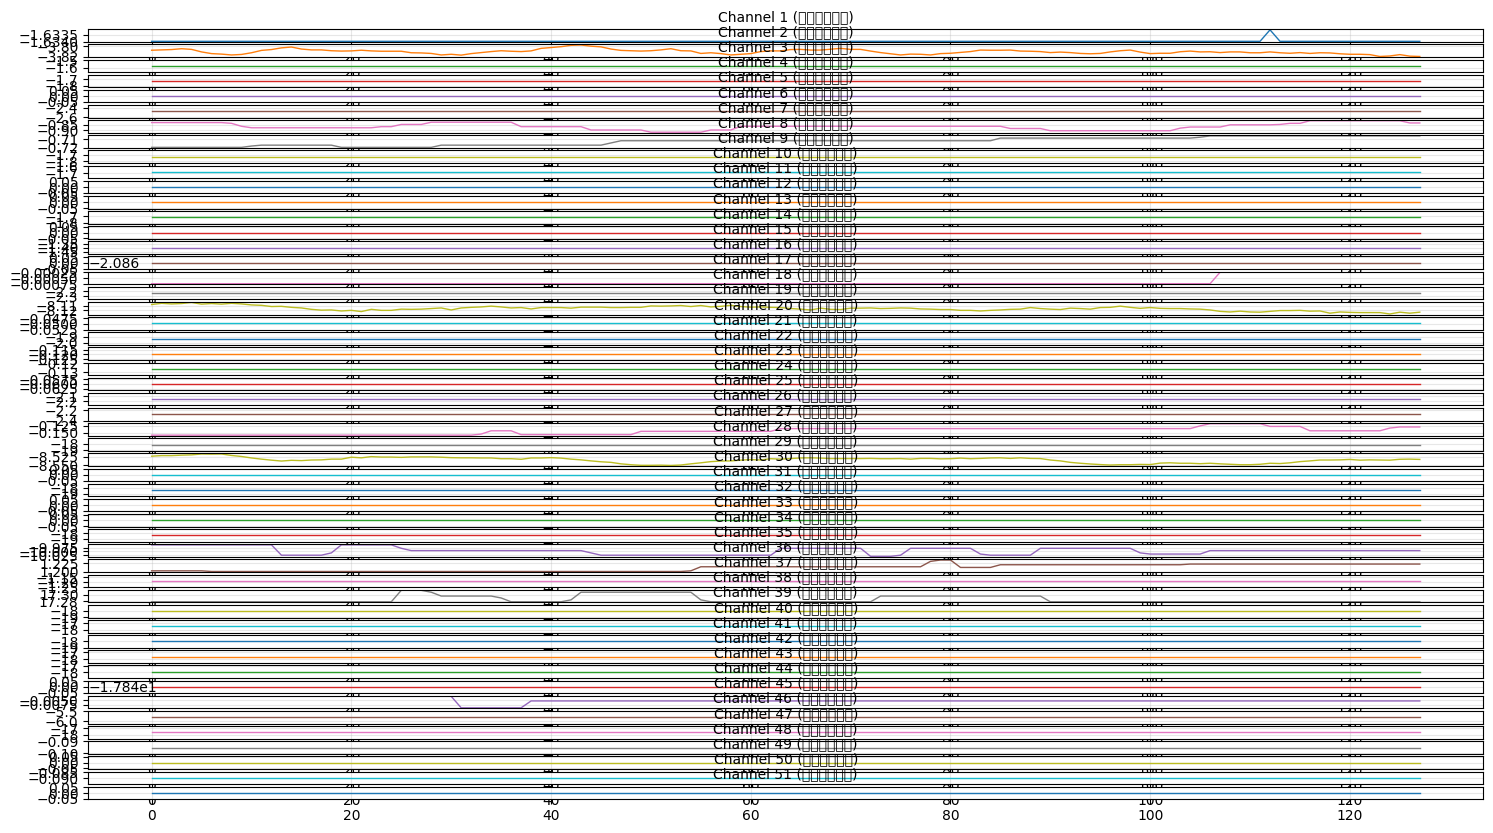

In [35]:
import matplotlib.pyplot as plt
import torch
import numpy as np

# ----------------------
# 假设你已经拿到了 data (形状 [896, 6])
# ----------------------
# data, label = dataset[0]  # 你原本取数据的代码

# 如果你没有真实数据，可以用下面这行模拟测试
# data = torch.randn(896, 6)
data=ueadataset[0][0]
data=swatdataset[0][0]
# 转为 numpy 方便画图
signal = data  # shape: (896, 6)
seq_len, feat_dim = signal.shape

# ----------------------
# 绘制 6 个通道的波形（像工业电流信号）
# ----------------------
plt.figure(figsize=(18, 10))

for i in range(feat_dim):
    plt.subplot(feat_dim, 1, i+1)  # 6行1列，每个通道一张图
    plt.plot(signal[:, i], linewidth=1.0, color=f"C{i}")
    plt.title(f"Channel {i+1} (一维时序信号)", fontsize=10)
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()